In [98]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings('ignore')

In [99]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/"
dataf = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_lai/"
datat = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_tropomi/"

band = 's'

In [100]:
fapar = xr.open_mfdataset(dataf+'*_'+band+'.nc')
precip = xr.open_dataset(datac+'chirps_10day_'+band+'.nc') 
lai = xr.open_mfdataset(datal+'lai_*_'+band+'.nc') 

In [101]:
tlist = []
for Y in range(2018,2025):
    t = xr.open_mfdataset(datat+'dD_'+str(Y)+'_10day_'+band+'.nc') 
    t = t.mean(dim=('scanline','ground_pixel')).load()
    tlist.append(t)
tropomi = xr.concat(tlist,dim='time')
    

In [102]:
fapar = fapar.mean(dim=('lat','lon')).load()
precip = precip.mean(dim=('lat','lon')).load()
lai = lai.mean(dim=('lat','lon')).load()

In [103]:
fapar_clim = fapar.groupby('time.dayofyear').mean('time')
precip_clim = precip.groupby('time.dayofyear').mean('time')
lai_clim = lai.groupby('time.dayofyear').mean('time')
dD_clim = tropomi.groupby('time.dayofyear').mean('time')

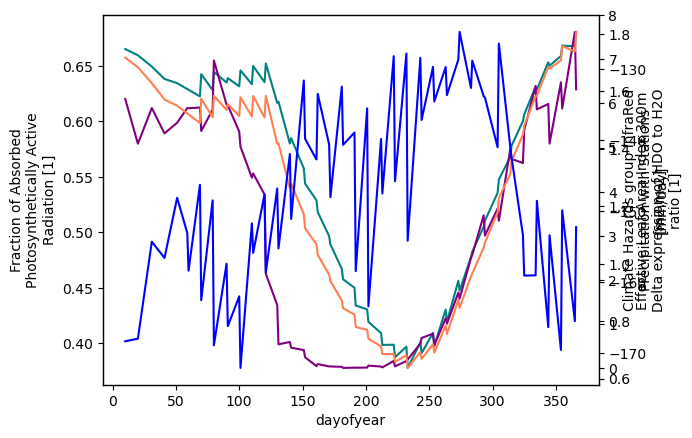

In [104]:
fig,ax = plt.subplots()
fapar_clim['fAPAR'].plot(color='teal',label='fAPAR',ax=ax)
ax2 = ax.twinx()
precip_clim['precip'].plot(color='purple',label='CHIRPS',ax=ax2)
ax3 = ax.twinx()
lai_clim['LAI'].plot(color='coral',label='LAI',ax=ax3)
ax4 = ax.twinx()
dD_clim['deltad'].plot(color='blue',linestyle='-',label='dD',ax=ax4)
plt.show()
plt.clf()
plt.close()
del fig
del ax

In [105]:
fapar_sns = fapar.to_dataframe()
precip_sns = precip.to_dataframe()
lai_sns = lai.to_dataframe()
tropomi_sns = tropomi.to_dataframe()
df = fapar_sns.join(precip_sns)
df = df.join(lai_sns)
df = df.join(tropomi_sns)

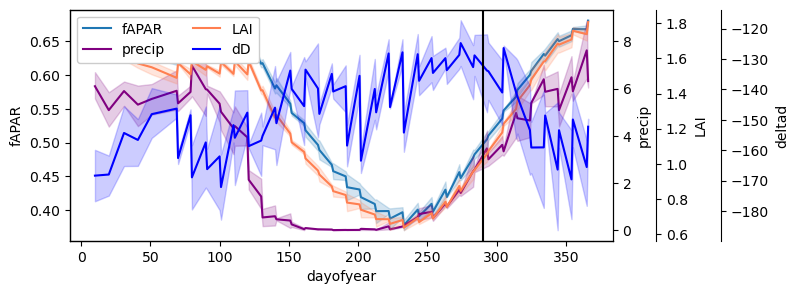

<Figure size 640x480 with 0 Axes>

In [106]:
df_clim = df.copy(deep=True)
df_clim.insert(0, "dayofyear", df_clim.index.dayofyear)
df_clim.insert(0, "year", df_clim.index.year)
fig,ax = plt.subplots(figsize=(7, 3))
sns.lineplot(data=df_clim, x="dayofyear", y="fAPAR",ax=ax,linestyle='-',label='fAPAR',legend=False)
ax2 = ax.twinx()
sns.lineplot(data=df_clim, x="dayofyear", y="precip",ax=ax2,color='purple',label='precip',legend=False)
ax3 = ax.twinx()
sns.lineplot(data=df_clim, x="dayofyear", y="LAI",ax=ax3,color='coral',label='LAI',legend=False)
ax4 = ax.twinx()
sns.lineplot(data=df_clim, x="dayofyear", y="deltad",ax=ax4,color='blue',label='dD',legend=False)
plt.axvline(x = 290, color = 'black')
#plt.axvline(x = 247, color = 'black')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.2))
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, ncols=2, loc='best')
plt.savefig(datap+'obs_clim_10days_'+band+'.png')
plt.show()
plt.clf()


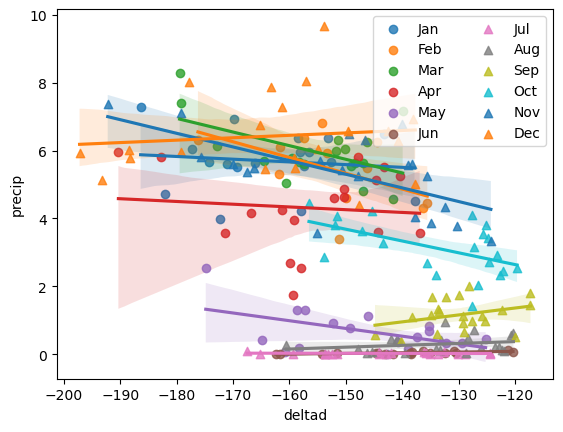

In [107]:
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
shp = ['o','o','o','o','o','o','^','^','^','^','^','^']
for m in range(1,13):
    df_m = df[df.index.month == m]
    sns.regplot(data=df_m, x="deltad", y="precip",label=mon[m-1],marker=shp[m-1])
    plt.legend(ncol=2)

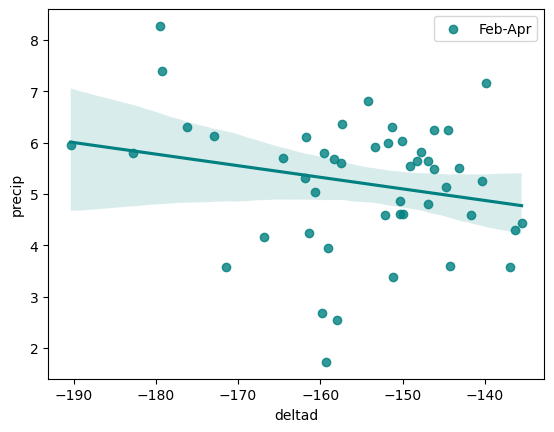

In [108]:
df_seas = df[df.index.month.isin([2,3,4])]
sns.regplot(data=df_seas, x="deltad", y="precip",label='Feb-Apr',ci=95,color='teal')
plt.legend()

In [109]:
fit_results = sm.OLS(df_seas['deltad'], df_seas['precip']).fit()
print(fit_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                 deltad   R-squared (uncentered):                   0.947
Model:                            OLS   Adj. R-squared (uncentered):              0.946
Method:                 Least Squares   F-statistic:                              837.9
Date:                Mon, 25 May 2026   Prob (F-statistic):                    1.31e-31
Time:                        20:58:39   Log-Likelihood:                         -239.98
No. Observations:                  48   AIC:                                      482.0
Df Residuals:                      47   BIC:                                      483.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [110]:
fapar_mean = fapar.groupby('time.dayofyear').mean('time')
fapar_std = fapar.groupby('time.dayofyear').std('time') 
fapar_mean = fapar_mean.sel(dayofyear=fapar.time.dt.dayofyear)
fapar_std = fapar_std.sel(dayofyear=fapar.time.dt.dayofyear)
fapar_zscore = (fapar - fapar_mean)/fapar_std
fapar_zscore = fapar_zscore.drop('dayofyear')

precip_mean = precip.groupby('time.dayofyear').mean('time')
precip_std = precip.groupby('time.dayofyear').std('time') 
precip_mean = precip_mean.sel(dayofyear=precip.time.dt.dayofyear)
precip_std = precip_std.sel(dayofyear=precip.time.dt.dayofyear)
precip_zscore = (precip - precip_mean)/precip_std
precip_zscore = precip_zscore.drop('dayofyear')

fapar_zscore_sns = fapar_zscore.to_dataframe()
precip_zscore_sns = precip_zscore.to_dataframe()
df_zscore = fapar_zscore_sns.join(precip_zscore_sns)

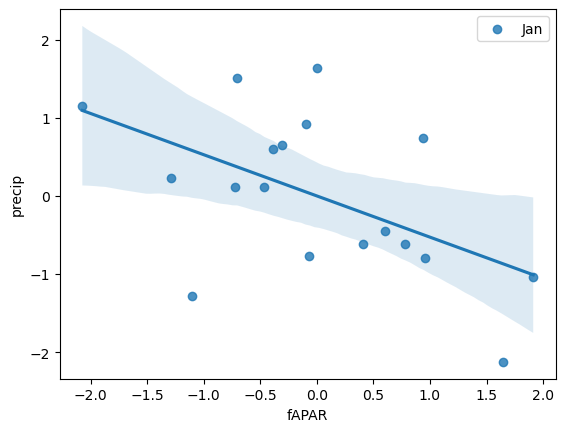

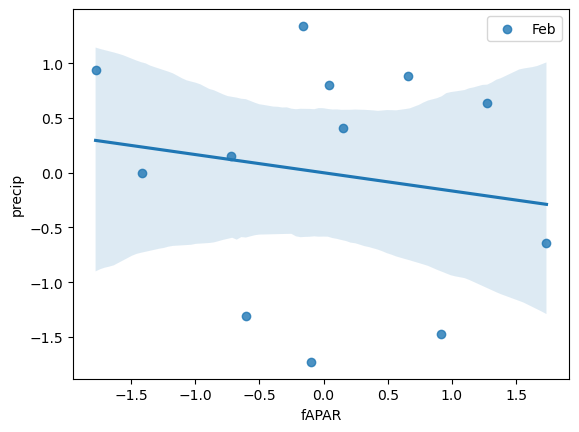

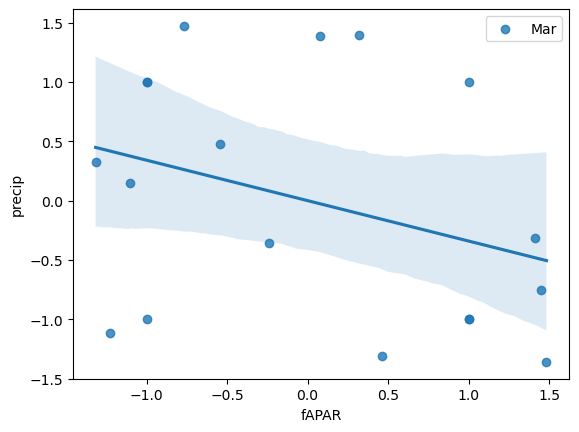

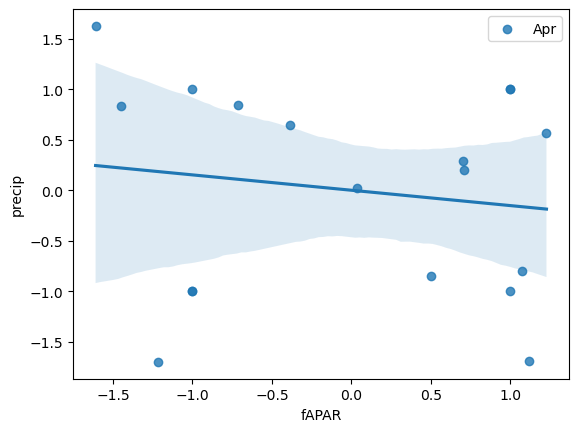

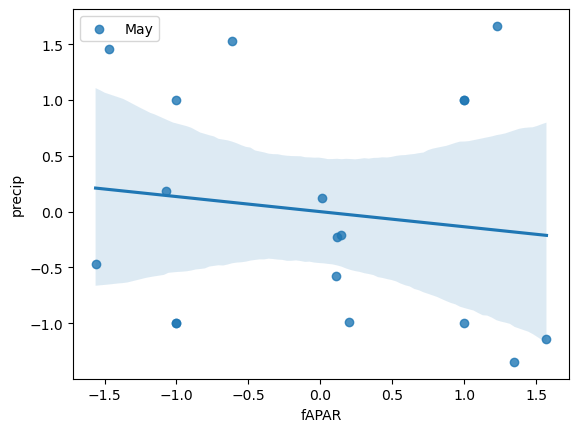

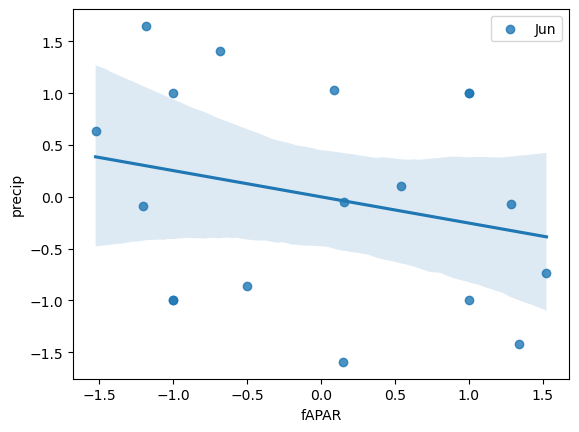

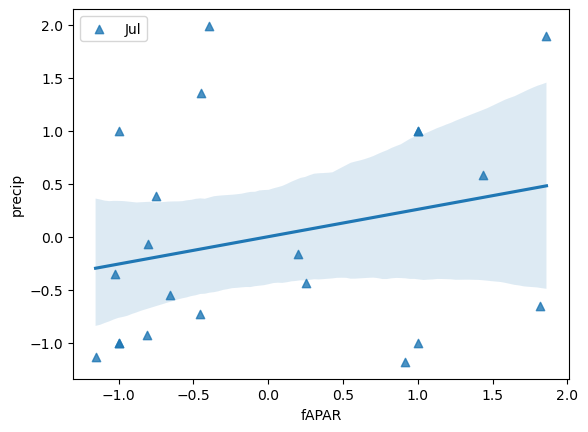

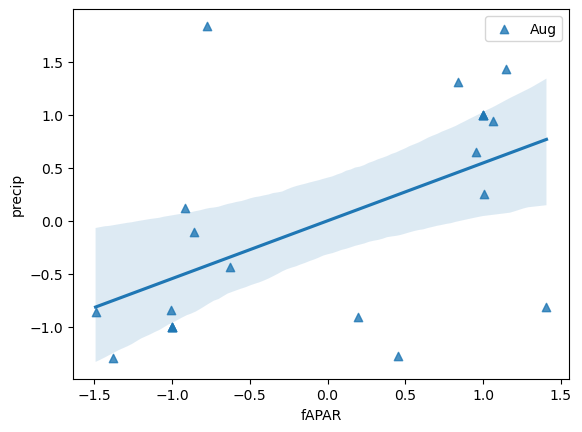

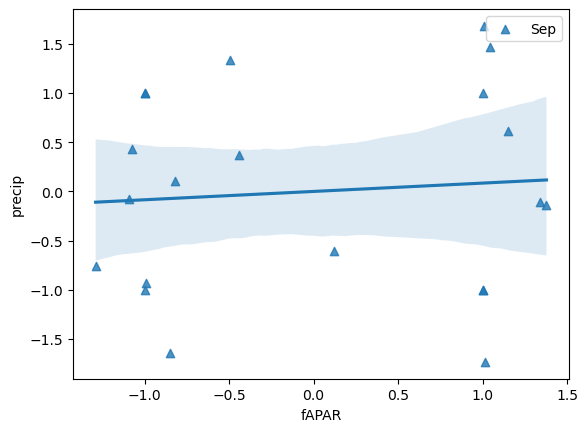

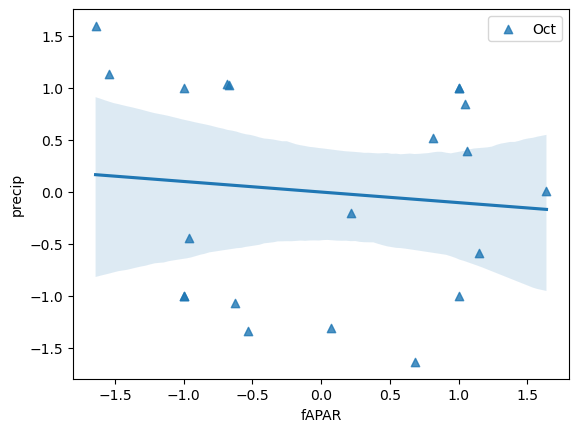

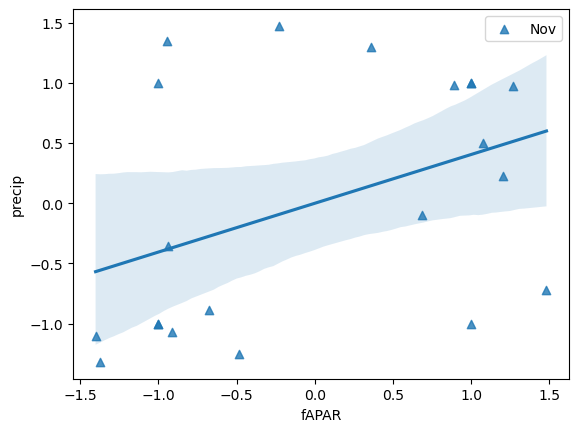

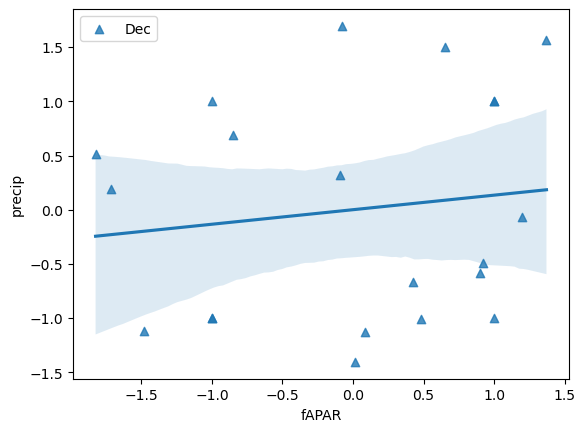

<Figure size 640x480 with 0 Axes>

In [111]:
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
shp = ['o','o','o','o','o','o','^','^','^','^','^','^']
for m in range(1,13):
    df_zscore_m = df_zscore[df_zscore.index.month == m]
    sns.regplot(data=df_zscore_m, x="fAPAR", y="precip",label=mon[m-1],marker=shp[m-1])
    plt.legend(ncol=2)
    plt.show()
    plt.clf()

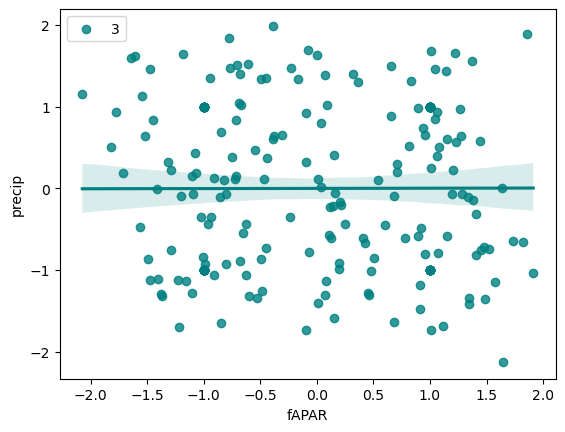

In [112]:
df_zscore_seas = df_zscore#[df_zscore.index.month.isin([8])]
#df_zscore_seas = df_zscore[(df_zscore.index.dayofyear>2) & (df_zscore.index.dayofyear<62)]
sns.regplot(data=df_zscore_seas, x="fAPAR", y="precip",label='3',ci=95,color='teal')
plt.legend()

In [113]:
fit_results = sm.OLS(df_zscore_seas['fAPAR'], df_zscore_seas['precip']).fit()
print(fit_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                  fAPAR   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.004
Method:                 Least Squares   F-statistic:                           0.001079
Date:                Mon, 25 May 2026   Prob (F-statistic):                       0.974
Time:                        20:58:40   Log-Likelihood:                         -323.52
No. Observations:                 228   AIC:                                      649.0
Df Residuals:                     227   BIC:                                      652.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------